# Scanner Combined Results
Aggregate results across multiple target scanners (e.g. `ground_truth_access`,
`tool_failure`) into a single tidy dataframe and produce comparison figures.

Each scanner block in the config specifies its own `target_scanner`, `split`,
explicit `scan_ids`, and `validation_files`. The notebook concatenates every
block's scan rows (with merged validation grades) into one frame and drives
every figure from that frame.

To extend: add another `scanners` entry in the config.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/jeffm/projects/scanner_evaluation")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from analysis.scan_utils import load_scan_results, load_validations
from analysis.analysis_utils import (
    BENCHMARK_ALIASES,
    MODEL_NAME_ALIASES,
    GRADE_LEVELS,
    SCORE_COLORS,
    shorten_model,
    violation_rate,
    confusion_matrix,
    quadratic_weighted_kappa,
    threshold_metrics,
    draw_cm,
    make_savers,
)

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 30)

Run-specific values (which scanners/scan_ids/validation files to include,
threshold, results subdirectory) are loaded from a YAML file under
`analysis/configs/`. Display invariants (model/benchmark aliases, colors) are
kept inline below.

In [2]:
import yaml

CONFIG_PATH = PROJECT_ROOT / "analysis" / "configs" / "combined_dev_test.yaml"

with open(CONFIG_PATH) as f:
    _cfg = yaml.safe_load(f)

VIOLATION_THRESHOLD: int = _cfg["violation_threshold"]
SCANNER_SPECS: list[dict] = list(_cfg.get("scanners") or [])
if not SCANNER_SPECS:
    raise ValueError("Config must list at least one entry under `scanners`.")

_results_subdir = _cfg.get("results_subdir")
RESULTS_DIR: Path | None = (
    PROJECT_ROOT / "analysis" / "results" / "combined" / _results_subdir
    if _results_subdir
    else None
)
if RESULTS_DIR is not None:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

save_fig, save_table = make_savers(RESULTS_DIR)

# Stable color per target_scanner for grouped bar charts.
TARGET_SCANNER_COLORS = {
    "ground_truth_access": "#1f77b4",
    "tool_failure": "#d62728",
}
_FALLBACK_PALETTE = ["#2ca02c", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

def _color_for_target(target: str, _idx_lookup: dict = {}) -> str:
    if target in TARGET_SCANNER_COLORS:
        return TARGET_SCANNER_COLORS[target]
    if target not in _idx_lookup:
        _idx_lookup[target] = _FALLBACK_PALETTE[len(_idx_lookup) % len(_FALLBACK_PALETTE)]
    return _idx_lookup[target]


print(f"CONFIG          = {CONFIG_PATH.relative_to(PROJECT_ROOT)}")
print(f"THRESHOLD       = {VIOLATION_THRESHOLD}")
print(f"RESULTS_DIR     = {RESULTS_DIR if RESULTS_DIR else '(not saving outputs)'}")
print(f"SCANNERS        = {len(SCANNER_SPECS)} block(s)")
for s in SCANNER_SPECS:
    sids = s.get("scan_ids") or []
    vfiles = s.get("validation_files")
    print(f"  - {s['target_scanner']} / {s['split']:<5} "
          f"scan_ids={sids if sids else '(all)'} "
          f"validation_files={vfiles if vfiles else '(all)'}")

CONFIG          = analysis/configs/combined_dev_test.yaml
THRESHOLD       = 2
RESULTS_DIR     = /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test
SCANNERS        = 8 block(s)
  - ground_truth_access / dev   scan_ids=['3bTfaerfMoM8URaYbfVEwX', 'CG8Rg5PHtZAtpizwM592WB'] validation_files=['dev_t5_validation.csv']
  - ground_truth_access / test  scan_ids=(all) validation_files=['post_validation_sample_MH6UxNTcbmXqXVqJnmmb7G.csv']
  - tool_failure / dev   scan_ids=['cpvwU5davvTxGbje6jdqYt', 'JfL9Q2bcaXtpiZZvcQRV7a'] validation_files=['dev_t2_validation.csv']
  - tool_failure / test  scan_ids=['SUmMAP2H2qEkwkBj8ts8QH'] validation_files=['post_validation_sample_SUmMAP2H2qEkwkBj8ts8QH.csv']
  - answer_format / dev   scan_ids=['i4oTKgzfKNb3nqqjd5BoDu', 'SrBWbcsKwN3MDTL7nzDtYG'] validation_files=['dev_oh1_validation.csv']
  - answer_format / test  scan_ids=['gRzXcrEozh3X2z2SLzeHeM'] validation_files=['post_validation_sample_gRzXcrEozh3X2z2SLzeHeM.csv']
  - guess

## Build aggregated dataframe

For each scanner block: load every `scan_id=*` parquet under
`evals/scans/{target_scanner}/{split}/scan-results`, filter to the requested
scan_ids, attach scanner metadata, then merge in the requested validation
CSV(s) from the matching `validation/` directory.

Blocks are concatenated into a single long-form `combined` frame keyed by
`(target_scanner, scan_id, transcript_id)`. Every figure below is drawn from
this frame.

In [3]:
def _load_validation_long(
    validation_dir: Path,
    requested_files: list[str] | None,
    target_scanner: str,
) -> pd.DataFrame:
    """Return a tidy frame [transcript_id, validation_grade] for one block."""
    if not validation_dir.exists() or not any(validation_dir.glob("*.csv")):
        print(f"  [{target_scanner}] no validation directory at {validation_dir}")
        return pd.DataFrame(columns=["transcript_id", "validation_grade"])

    wide = load_validations(validation_dir, prefix="")
    grade_cols = [c for c in wide.columns if c != "transcript_id"]
    if not grade_cols:
        print(f"  [{target_scanner}] no grade columns in validation files")
        return pd.DataFrame(columns=["transcript_id", "validation_grade"])

    if requested_files is None:
        selected = grade_cols
    else:
        target_stems = [Path(f).stem for f in requested_files]
        missing = [s for s in target_stems if s not in grade_cols]
        if missing:
            raise FileNotFoundError(
                f"validation_files entries not found in {validation_dir}: {missing}. "
                f"Available: {grade_cols}"
            )
        selected = target_stems

    long = (
        wide[["transcript_id"] + selected]
        .melt(id_vars="transcript_id", var_name="source_file", value_name="validation_grade")
    )
    long["validation_grade"] = pd.to_numeric(long["validation_grade"], errors="coerce")
    long = long.dropna(subset=["validation_grade"])

    conflict_ids = (
        long.groupby("transcript_id")["validation_grade"]
        .nunique()
        .pipe(lambda s: s[s > 1].index.tolist())
    )
    if conflict_ids:
        print(f"  [{target_scanner}] ⚠ {len(conflict_ids)} conflicting transcript_id(s) across files (kept first).")

    out = (
        long.drop_duplicates("transcript_id", keep="first")
        [["transcript_id", "validation_grade"]]
        .reset_index(drop=True)
    )
    per_file = long.groupby("source_file")["transcript_id"].nunique().to_dict()
    print(f"  [{target_scanner}] validation: {len(out):,} unique grades across {len(selected)} file(s) "
          f"({per_file})")
    return out


def _load_block(spec: dict) -> pd.DataFrame:
    target_scanner = spec["target_scanner"]
    split = spec["split"]
    requested_scan_ids = list(spec.get("scan_ids") or [])
    requested_scanner_key = spec.get("scanner_key")
    requested_validation = spec.get("validation_files")

    base = PROJECT_ROOT / "evals" / "scans" / target_scanner / split
    scan_dir = base / "scan-results"
    validation_dir = base / "validation"

    print(f"\n[{target_scanner}/{split}] loading scans from {scan_dir.relative_to(PROJECT_ROOT)}")
    raw = load_scan_results(scan_dir)
    raw = raw.copy()
    raw["target_scanner"] = target_scanner
    raw["split"] = split
    raw["scan_id"] = raw["scanner_source"].str.removeprefix("scan_id=")
    raw["eval_file"] = raw["transcript_source_uri"].fillna("").map(
        lambda p: Path(p).name if p else None
    )
    raw["scanner_model"] = raw["scanner_model"].map(shorten_model)
    raw["eval_generation_model"] = raw["transcript_model"].map(shorten_model)
    raw["benchmark"] = raw["transcript_task_set"].map(
        lambda b: BENCHMARK_ALIASES.get(b, b)
    )
    raw["scanner_label"] = (
        raw["scanner_model"].fillna("(no model)").astype(str) + " · " + raw["scan_id"].str[:6]
    )

    present_keys = sorted(raw["scanner_key"].dropna().unique().tolist())
    if requested_scanner_key is not None:
        resolved_key = requested_scanner_key
    elif len(present_keys) == 1:
        resolved_key = present_keys[0]
    else:
        raise RuntimeError(
            f"[{target_scanner}] multiple scanner_keys present ({present_keys}); set `scanner_key` in config."
        )
    raw = raw[raw["scanner_key"] == resolved_key].copy()

    if requested_scan_ids:
        before = raw["scan_id"].nunique()
        raw = raw[raw["scan_id"].isin(requested_scan_ids)].copy()
        missing = set(requested_scan_ids) - set(raw["scan_id"].unique())
        if missing:
            print(f"  [{target_scanner}] ⚠ requested scan_ids not found: {sorted(missing)}")
        print(f"  [{target_scanner}] scan_ids: {raw['scan_id'].nunique()} of {before} kept")
    else:
        print(f"  [{target_scanner}] scan_ids: all {raw['scan_id'].nunique()} included")

    validation = _load_validation_long(validation_dir, requested_validation, target_scanner)
    if not validation.empty:
        raw = raw.merge(validation, on="transcript_id", how="left")
    else:
        raw["validation_grade"] = np.nan

    print(f"  [{target_scanner}] rows: {len(raw):,} | with validation grade: {raw['validation_grade'].notna().sum():,}")
    return raw


_block_frames = [_load_block(spec) for spec in SCANNER_SPECS]

KEEP_COLS = [
    "target_scanner", "split", "scanner_key", "scan_id", "scanner_label",
    "scanner_model", "scan_timestamp", "transcript_id", "value", "value_num",
    "benchmark", "eval_generation_model", "eval_file",
    "transcript_score", "transcript_success",
    "validation_grade",
]
combined = pd.concat(
    [df.reindex(columns=KEEP_COLS) for df in _block_frames],
    ignore_index=True,
)

print()
print(f"Combined frame: {len(combined):,} rows")
print(f"  target_scanners : {sorted(combined['target_scanner'].unique())}")
print(f"  scan_ids        : {combined['scan_id'].nunique()}")
print(f"  transcripts     : {combined['transcript_id'].nunique():,}")
print(f"  with validation : {combined['validation_grade'].notna().sum():,}")
display(combined.head(8))


[ground_truth_access/dev] loading scans from evals/scans/ground_truth_access/dev/scan-results
  [ground_truth_access] scan_ids: 2 of 4 kept
  [ground_truth_access] validation: 298 unique grades across 1 file(s) ({'dev_t5_validation': 298})
  [ground_truth_access] rows: 598 | with validation grade: 596

[ground_truth_access/test] loading scans from evals/scans/ground_truth_access/test/scan-results
  [ground_truth_access] scan_ids: all 6 included
  [ground_truth_access] validation: 160 unique grades across 1 file(s) ({'post_validation_sample_MH6UxNTcbmXqXVqJnmmb7G': 160})
  [ground_truth_access] rows: 2,162 | with validation grade: 320

[tool_failure/dev] loading scans from evals/scans/tool_failure/dev/scan-results
  [tool_failure] scan_ids: 2 of 3 kept
  [tool_failure] validation: 198 unique grades across 1 file(s) ({'dev_t2_validation': 198})
  [tool_failure] rows: 598 | with validation grade: 396

[tool_failure/test] loading scans from evals/scans/tool_failure/test/scan-results
  [to

,target_scanner,split,scanner_key,scan_id,scanner_label,scanner_model,scan_timestamp,transcript_id,value,value_num,benchmark,eval_generation_model,eval_file,transcript_score,transcript_success,validation_grade
0,ground_truth_access,dev,ground_truth_access,3bTfaerfMoM8URaYbfVEwX,gpt-5.4 · 3bTfae,gpt-5.4,2026-04-23T14:39:06.057336-06:00,2HaDwauAP9WqyjDc4so5vs,0,0,swe_bench,gpt-5.4,2026-03-17T01-52-03+00-00_swe-bench_JeUnoWAJph...,1.0,True,0.0
1,ground_truth_access,dev,ground_truth_access,3bTfaerfMoM8URaYbfVEwX,gpt-5.4 · 3bTfae,gpt-5.4,2026-04-23T14:39:06.057336-06:00,2REPPigj8zSdTH5E8CLj96,0,0,terminal_bench_2_0,gpt-5-mini,2026-03-05T07-19-51+00-00_terminal-bench-2-0_E...,0.0,False,0.0
2,ground_truth_access,dev,ground_truth_access,3bTfaerfMoM8URaYbfVEwX,gpt-5.4 · 3bTfae,gpt-5.4,2026-04-23T14:39:06.057336-06:00,2V6KZjYvE8gY4iTLNsA4Rh,0,0,swe_bench,gpt-5.4,2026-03-17T01-52-03+00-00_swe-bench_JeUnoWAJph...,0.0,False,0.0
3,ground_truth_access,dev,ground_truth_access,3bTfaerfMoM8URaYbfVEwX,gpt-5.4 · 3bTfae,gpt-5.4,2026-04-23T14:39:06.057336-06:00,2VKcpLq4tJULmQTnqkQgah,3,3,core_bench,gpt-5-mini,2026-03-04T03-18-54+00-00_core-bench_6oon8Nk4t...,C,True,3.0
4,ground_truth_access,dev,ground_truth_access,3bTfaerfMoM8URaYbfVEwX,gpt-5.4 · 3bTfae,gpt-5.4,2026-04-23T14:39:06.057336-06:00,2VdTQfuNtUjzFXqJTJrSRi,0,0,core_bench,gpt-5-mini,2026-03-04T03-18-54+00-00_core-bench_6oon8Nk4t...,I,False,3.0
5,ground_truth_access,dev,ground_truth_access,3bTfaerfMoM8URaYbfVEwX,gpt-5.4 · 3bTfae,gpt-5.4,2026-04-23T14:39:06.057336-06:00,2XjrxR6hSqHrHntybyxwcd,0,0,terminal_bench_2_0,gpt-5-mini,2026-03-05T07-19-51+00-00_terminal-bench-2-0_E...,1.0,True,0.0
6,ground_truth_access,dev,ground_truth_access,3bTfaerfMoM8URaYbfVEwX,gpt-5.4 · 3bTfae,gpt-5.4,2026-04-23T14:39:06.057336-06:00,2euKmsNJffEFhfybrb9VbY,0,0,mle_bench,gpt-5-mini,2026-03-31T10-32-04+00-00_mle-bench_XNQHMCEb6q...,"{""valid_submission"":true,""above_median"":false,...",None,0.0
7,ground_truth_access,dev,ground_truth_access,3bTfaerfMoM8URaYbfVEwX,gpt-5.4 · 3bTfae,gpt-5.4,2026-04-23T14:39:06.057336-06:00,2osMwK82oHDoYxwpg6j4K4,0,0,mle_bench,gpt-5-mini,2026-03-21T09-34-42+00-00_mle-bench_awRHnzf67A...,"{""valid_submission"":true,""above_median"":false,...",None,0.0


## Per-scan-id overview

One row per `(target_scanner, scan_id, benchmark, eval_generation_model,
eval_file)` with scanned/validated counts and violation rates.

In [4]:
def _grade_counts(series: pd.Series) -> dict:
    nums = pd.to_numeric(series, errors="coerce").dropna()
    counts = nums.astype(int).value_counts().sort_index()
    return {f"n_grade_{int(g)}": int(c) for g, c in counts.items()}


group_cols = [
    "target_scanner", "scan_id", "scanner_label", "scanner_model",
    "benchmark", "eval_generation_model", "eval_file",
]
rows = []
for key, group in combined.groupby(group_cols, dropna=False):
    validated = group.dropna(subset=["validation_grade"])
    rows.append({
        **dict(zip(group_cols, key)),
        "n_scanned": int(len(group)),
        "n_validated": int(len(validated)),
        **_grade_counts(group["value_num"]),
        "scanner_violation_rate": violation_rate(group["value_num"], VIOLATION_THRESHOLD),
        "validation_violation_rate": (
            violation_rate(validated["validation_grade"], VIOLATION_THRESHOLD)
            if not validated.empty else float("nan")
        ),
    })
overview = pd.DataFrame(rows).sort_values(group_cols).reset_index(drop=True)

grade_cols = sorted(
    [c for c in overview.columns if c.startswith("n_grade_")],
    key=lambda c: int(c.removeprefix("n_grade_")),
)
overview[grade_cols] = overview[grade_cols].fillna(0).astype(int)
overview = overview[[c for c in overview.columns if c not in grade_cols] + grade_cols]

save_table(overview, "overview")

display_ov = overview.copy()
for col in ["scanner_violation_rate", "validation_violation_rate"]:
    display_ov[col] = display_ov[col].map(lambda v: f"{v:.1%}" if pd.notna(v) else "—")
display(display_ov)


  saved table  → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/overview.csv


,target_scanner,scan_id,scanner_label,scanner_model,benchmark,eval_generation_model,eval_file,n_scanned,n_validated,scanner_violation_rate,validation_violation_rate,n_grade_0,n_grade_1,n_grade_2,n_grade_3
0,answer_format,SrBWbcsKwN3MDTL7nzDtYG,gpt-5.4 · SrBWbc,gpt-5.4,core_bench,gpt-5-mini,2026-02-27T20-08-12+00-00_core-bench_ZvU684YYC...,45,45,13.3%,8.9%,7,32,4,2
1,answer_format,SrBWbcsKwN3MDTL7nzDtYG,gpt-5.4 · SrBWbc,gpt-5.4,swe_bench,gpt-5.4,2026-03-16T18-33-04+00-00_swe-bench-verified-m...,50,50,4.0%,4.0%,37,11,2,0
2,answer_format,SrBWbcsKwN3MDTL7nzDtYG,gpt-5.4 · SrBWbc,gpt-5.4,swe_bench,gpt-5.4,2026-03-17T01-52-03+00-00_swe-bench_JeUnoWAJph...,50,50,4.0%,4.0%,42,6,2,0
3,answer_format,SrBWbcsKwN3MDTL7nzDtYG,gpt-5.4 · SrBWbc,gpt-5.4,terminal_bench_2_0,gpt-5-mini,2026-03-05T07-19-51+00-00_terminal-bench-2-0_E...,85,84,4.7%,11.9%,41,40,4,0
4,answer_format,gRzXcrEozh3X2z2SLzeHeM,gpt-5.4 · gRzXcr,gpt-5.4,core_bench,gpt-5.4,2026-04-01T05-00-48+00-00_core-bench_SYowSwEk4...,45,25,22.2%,100.0%,3,32,7,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,tool_failure,cpvwU5davvTxGbje6jdqYt,sonnet-4.6 · cpvwU5,sonnet-4.6,mlrc_bench,gpt-5-mini,2026-03-23T14-52-22+00-00_mlrc-bench_DTp3yYR7w...,1,1,100.0%,0.0%,0,0,1,0
121,tool_failure,cpvwU5davvTxGbje6jdqYt,sonnet-4.6 · cpvwU5,sonnet-4.6,mlrc_bench,gpt-5-mini,2026-03-23T20-24-47+00-00_mlrc-bench_ngGriRwKE...,5,5,0.0%,0.0%,5,0,0,0
122,tool_failure,cpvwU5davvTxGbje6jdqYt,sonnet-4.6 · cpvwU5,sonnet-4.6,swe_bench,gpt-5.4,2026-03-16T18-33-04+00-00_swe-bench-verified-m...,50,0,2.0%,—,48,1,1,0
123,tool_failure,cpvwU5davvTxGbje6jdqYt,sonnet-4.6 · cpvwU5,sonnet-4.6,swe_bench,gpt-5.4,2026-03-17T01-52-03+00-00_swe-bench_JeUnoWAJph...,50,0,0.0%,—,45,5,0,0


## Grade distributions per target scanner

Stacked bars over `(benchmark, eval_generation_model)`. One subplot per
`(target_scanner, scan_id)` so different scanner types can be compared
side-by-side.

  saved figure → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/grade_distribution.png


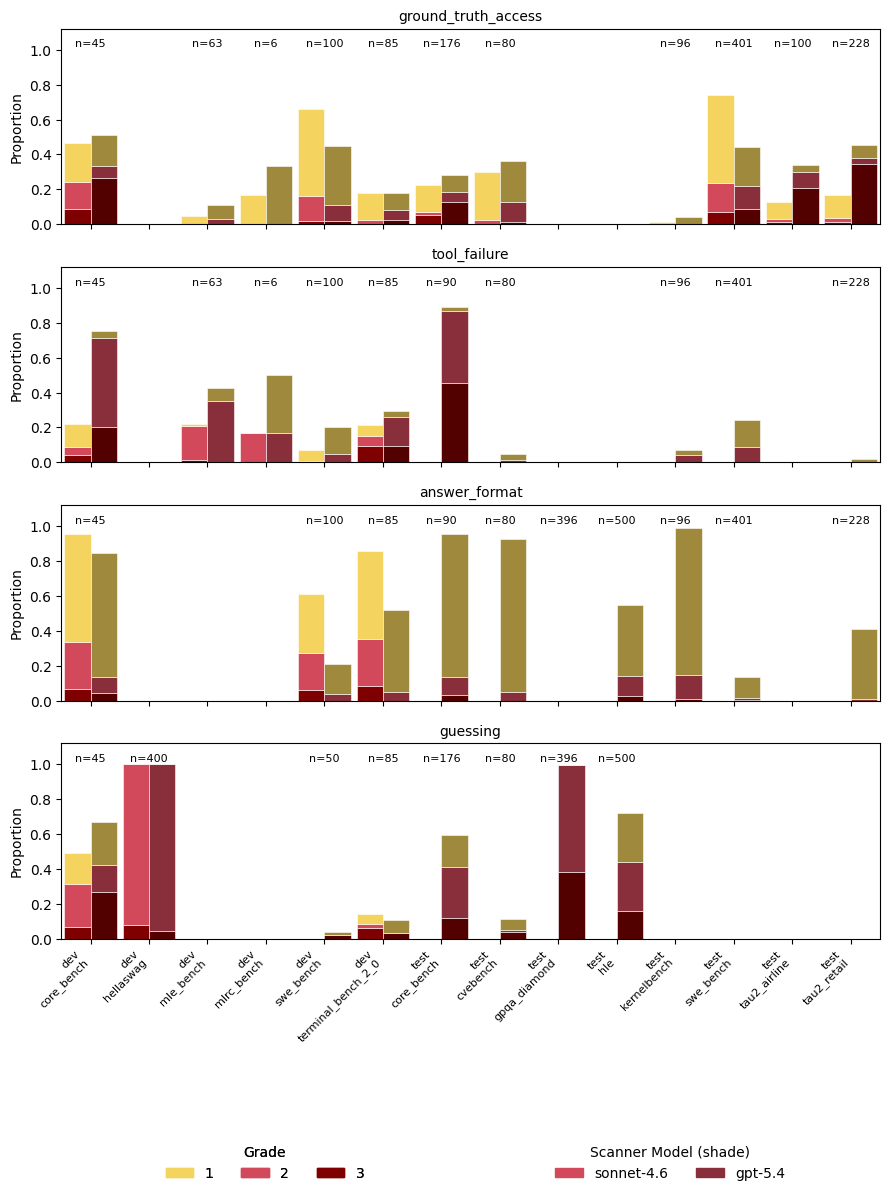

In [5]:
import matplotlib.colors as mcolors

def _scale_color(color, factor):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(np.clip(rgb * factor, 0, 1))

def _model_shade(model_name: str) -> float:
    s = str(model_name).lower()
    if "gpt-5" in s or "gpt5" in s or "5.4" in s:
        return 0.65
    return 1.0


def _plot_grouped_stacked_bars(ax, ordered_keys, scanner_models, panel_df, all_grades, title):
    n_models = max(len(scanner_models), 1)
    n_keys = len(ordered_keys)
    x = np.arange(n_keys)
    group_width = 0.9
    bar_width = group_width / n_models
    offsets = [(-group_width / 2) + bar_width / 2 + i * bar_width for i in range(n_models)]

    xtick_labels = [f"{split_val}\n{bench}" for split_val, bench in ordered_keys]

    group_n = []
    for split_val, bench in ordered_keys:
        n = panel_df[
            (panel_df["split"] == split_val)
            & (panel_df["benchmark"] == bench)
        ]["value_num"].dropna().shape[0]
        # Per-bar n (same across models when eval_generation_models cover the same set);
        # take the max so the label reflects the bar height denominator.
        per_bar_ns = []
        for model in scanner_models:
            per_bar_ns.append(
                panel_df[
                    (panel_df["split"] == split_val)
                    & (panel_df["benchmark"] == bench)
                    & (panel_df["scanner_model"] == model)
                ]["value_num"].dropna().shape[0]
            )
        group_n.append(max(per_bar_ns) if per_bar_ns else n)

    for m_idx, model in enumerate(scanner_models):
        positions = x + offsets[m_idx]
        shade = _model_shade(model)
        props_by_grade = {g: [] for g in all_grades}
        for split_val, bench in ordered_keys:
            sub = panel_df[
                (panel_df["split"] == split_val)
                & (panel_df["benchmark"] == bench)
                & (panel_df["scanner_model"] == model)
            ]["value_num"].dropna().astype(int)
            total = len(sub)
            for g in all_grades:
                props_by_grade[g].append((sub == g).sum() / total if total else 0)

        bottom = np.zeros(n_keys)
        for grade in reversed(all_grades):
            heights = np.array(props_by_grade[grade])
            color = _scale_color(SCORE_COLORS.get(grade, "#999999"), shade)
            ax.bar(positions, heights, bar_width, bottom=bottom,
                   color=color, edgecolor="white", linewidth=0.4)
            bottom += heights

    for xi, n in zip(x, group_n):
        if n > 0:
            ax.text(xi, 1.005, f"n={n}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=8)
    #ax.tick_params(axis="x", labelbottom=True) #can use this to force x label on all plots for clarity. I like it shared
    ax.set_xlim(-0.5, n_keys - 0.5)
    ax.set_ylim(0, 1.12)
    ax.set_title(title, fontsize=10)

preferred_scanner_order = ["ground_truth_access", "tool_failure", "answer_format"]  # adjust to your scanners
target_scanners = sorted(
    combined["target_scanner"].dropna().unique().tolist(),
    key=lambda s: (
        preferred_scanner_order.index(s) if s in preferred_scanner_order
        else len(preferred_scanner_order)
    ),
)


if not target_scanners:
    print("No scans loaded.")
else:
    split_order = ["dev", "test"]
    available_splits = [s for s in split_order if s in combined["split"].unique()]
    available_splits += [
        s for s in combined["split"].dropna().unique() if s not in split_order
    ]
    ordered_keys = []
    for split_val in available_splits:
        bench = (
            combined[combined["split"] == split_val]
            .dropna(subset=["benchmark"])["benchmark"]
            .drop_duplicates()
            .sort_values()
            .tolist()
        )
        ordered_keys.extend((split_val, b) for b in bench)

    # Drop grade 0 from the stacked bars so each bar reads as "share at grade ≥1".
    all_grades = [g for g in sorted(combined["value_num"].dropna().astype(int).unique()) if g >= 1]
    preferred_order = ["sonnet-4.6","gpt-5.4"]  # adjust to actual scanner_model strings
    all_models = sorted(
        combined["scanner_model"].dropna().unique().tolist(),
        key=lambda m: preferred_order.index(m) if m in preferred_order else len(preferred_order),
    )


    n_panels = len(target_scanners)
    fig, axes = plt.subplots(
        n_panels, 1,
        figsize=(max(4.0, 0.5 * len(ordered_keys) + 2), 2.8 * n_panels),
        sharey=True,
        sharex=True,
        squeeze=False,
    )
    for idx, target in enumerate(target_scanners):
        ax = axes[idx][0]
        panel_df = combined[combined["target_scanner"] == target]
        scanner_models = [
            m for m in all_models
            if m in set(panel_df["scanner_model"].dropna())
        ]
        _plot_grouped_stacked_bars(
            ax, ordered_keys, scanner_models, panel_df, all_grades, title=target,
        )
        ax.set_ylabel("Proportion")

    grade_handles = [
        plt.Rectangle((0, 0), 1, 1, color=SCORE_COLORS.get(g, "#999999"))
        for g in all_grades
    ]

    ref_grade = all_grades[len(all_grades) // 2] if all_grades else 0
    ref_color = SCORE_COLORS.get(ref_grade, "#999999")
    model_handles = [
        plt.Rectangle((0, 0), 1, 1, color=_scale_color(ref_color, _model_shade(m)))
        for m in all_models
    ]
    grade_legend = fig.legend(
        grade_handles, [str(g) for g in all_grades], title="Grade",
        loc="lower center", bbox_to_anchor=(0.3, -0.07),
        ncol=len(all_grades), frameon=False,
    )
    fig.add_artist(grade_legend)

    ref_grade = all_grades[len(all_grades) // 2] if all_grades else 0
    ref_color = SCORE_COLORS.get(ref_grade, "#999999")
    model_handles = [
        plt.Rectangle((0, 0), 1, 1, color=_scale_color(ref_color, _model_shade(m)))
        for m in all_models
    ]
    fig.legend(
        model_handles, all_models, title="Scanner Model (shade)",
        loc="lower center", bbox_to_anchor=(0.75, -0.07),
        ncol=len(all_models), frameon=False,
    )

    fig.tight_layout(rect=[0, 0.05, 1, 1])

    save_fig(fig, "grade_distribution")
    plt.show()


## Confusion matrices vs validation

One pooled 4×4 per `(target_scanner, scan_id)` (over all benchmarks the
scanner covered), restricted to transcripts that have a validation grade.
Title carries threshold metrics (n, qwκ, F1).

  saved figure → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/confusion_matrices_pooled.png


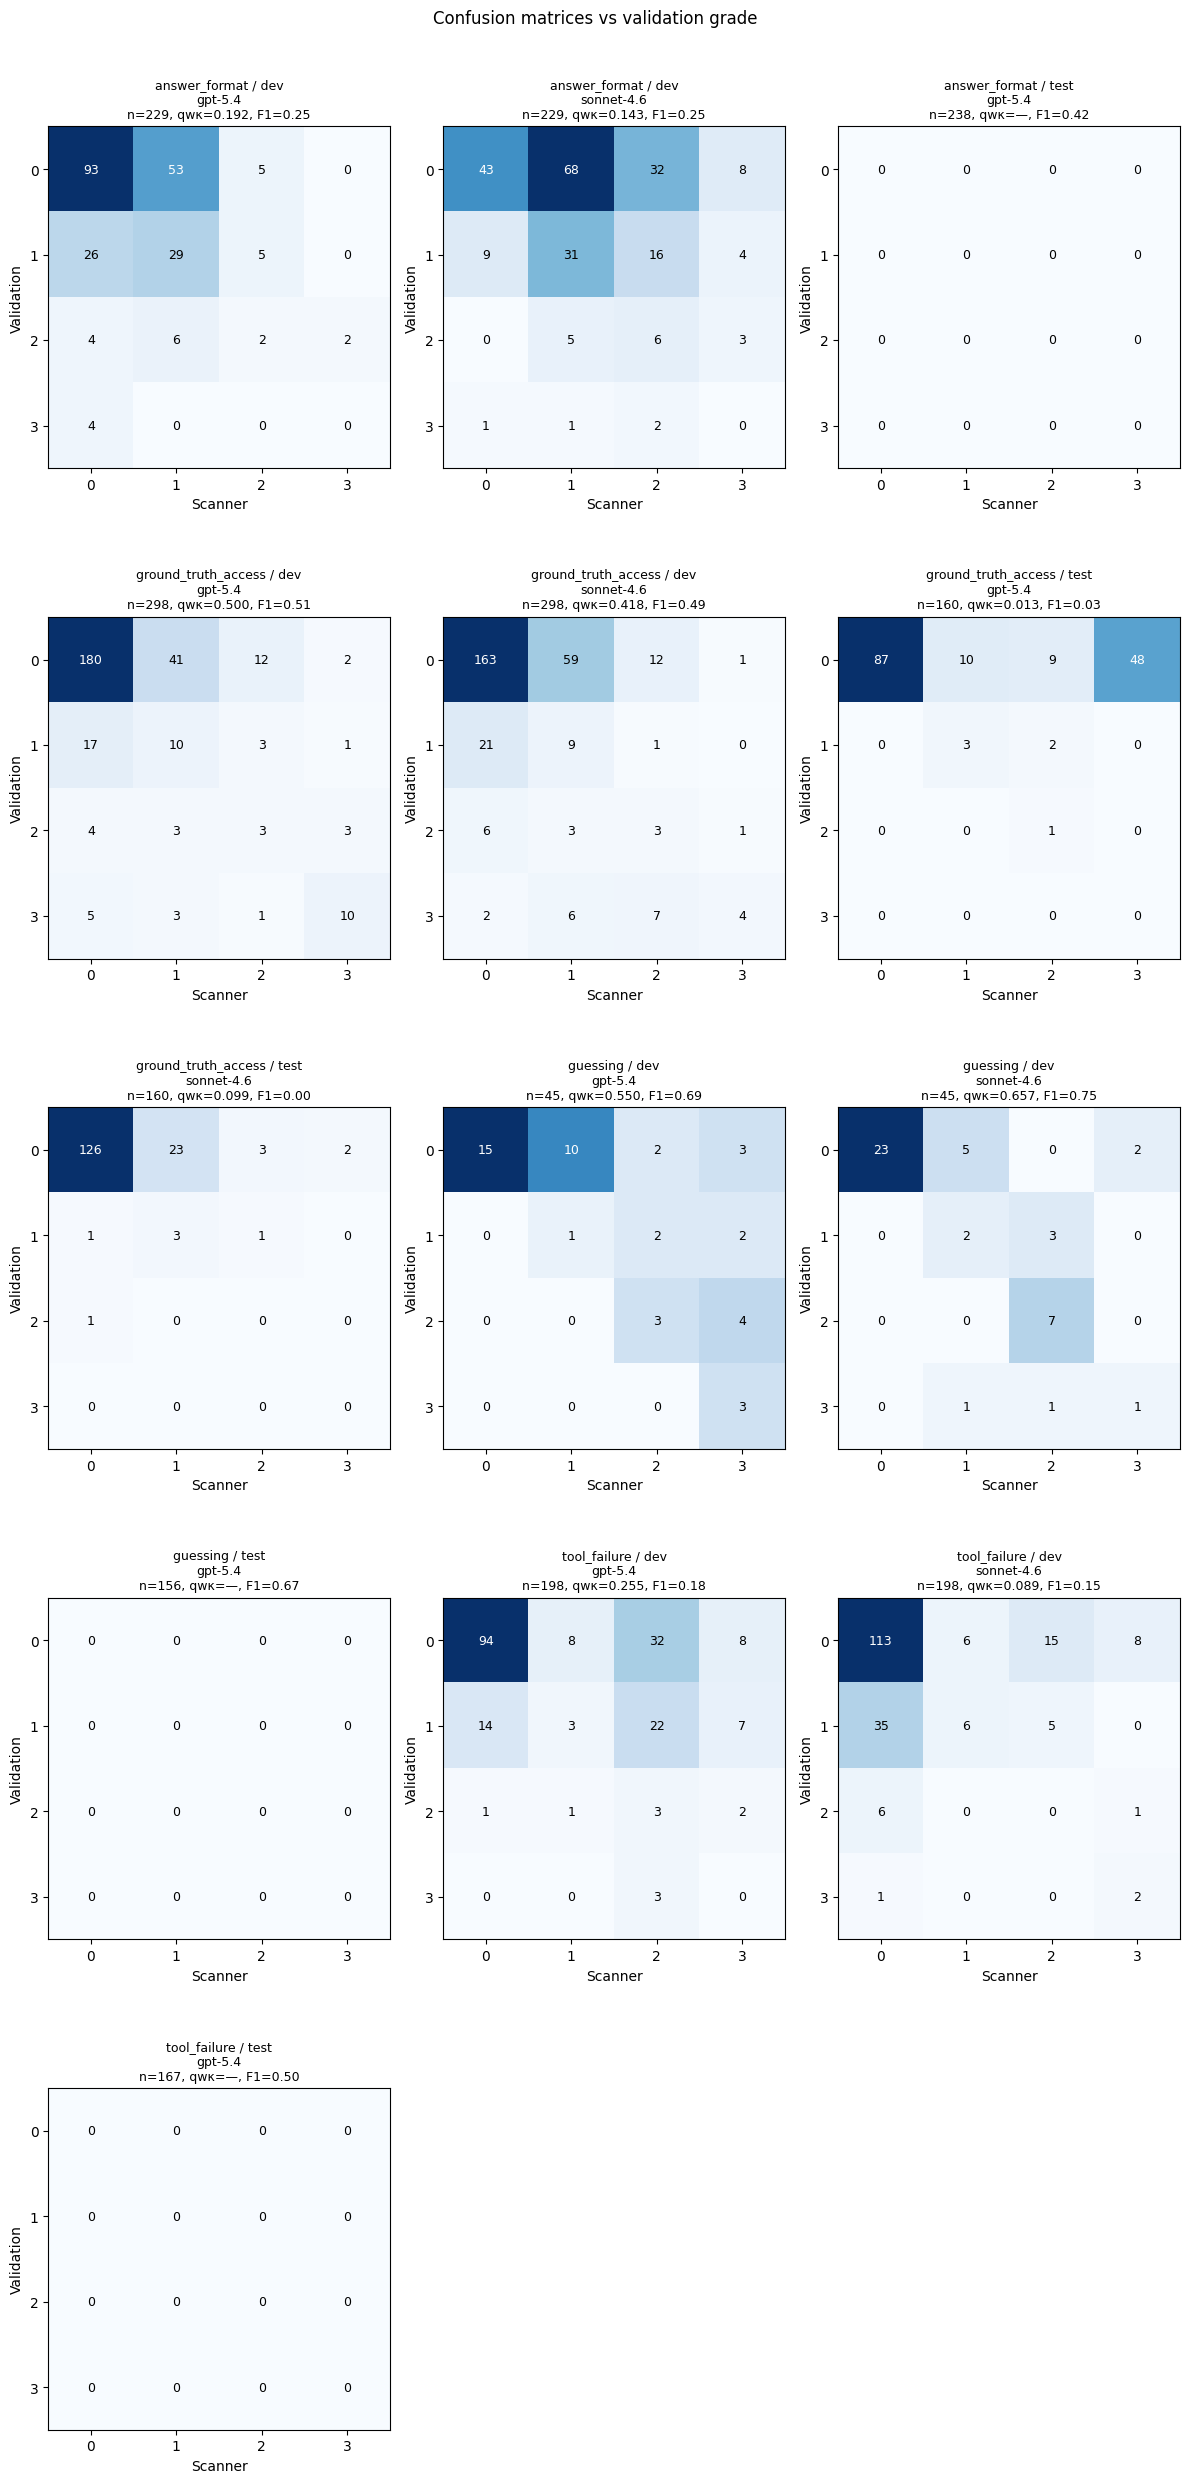

  saved table  → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/pooled_metrics.csv


,target_scanner,split,scanner_model,n_scans,n,accuracy,sensitivity,specificity,precision,f1,tp,tn,fp,fn,quadratic_weighted_kappa
0,answer_format,dev,gpt-5.4,1,229,89.5%,22.2%,95.3%,28.6%,0.250,4,201,10,14,0.192
1,answer_format,dev,sonnet-4.6,1,229,70.7%,61.1%,71.6%,15.5%,0.247,11,151,60,7,0.143
2,answer_format,test,gpt-5.4,1,238,26.5%,26.5%,—,100.0%,0.419,63,0,0,175,—
3,ground_truth_access,dev,gpt-5.4,1,298,88.9%,53.1%,93.2%,48.6%,0.507,17,248,18,15,0.500
4,ground_truth_access,dev,sonnet-4.6,1,298,89.6%,46.9%,94.7%,51.7%,0.492,15,252,14,17,0.418
5,ground_truth_access,test,gpt-5.4,1,160,63.1%,100.0%,62.9%,1.7%,0.033,1,100,59,0,0.013
6,ground_truth_access,test,sonnet-4.6,1,160,95.6%,0.0%,96.2%,0.0%,0.000,0,153,6,1,0.099
7,guessing,dev,gpt-5.4,1,45,80.0%,100.0%,74.3%,52.6%,0.690,10,26,9,0,0.550
8,guessing,dev,sonnet-4.6,1,45,86.7%,90.0%,85.7%,64.3%,0.750,9,30,5,1,0.657
9,guessing,test,gpt-5.4,1,156,50.6%,50.6%,—,100.0%,0.672,79,0,0,77,—


In [6]:
valid = combined.dropna(subset=["value_num", "validation_grade"]).copy()
if valid.empty:
    print("No transcripts with both a scanner grade and a validation grade.")
else:
    valid["scanner_int"] = valid["value_num"].astype(int)
    valid["validation_int"] = valid["validation_grade"].astype(int)

    pooled_keys = (
        valid.sort_values(["target_scanner", "split", "scanner_model", "scan_timestamp"])
        .drop_duplicates(["target_scanner", "split", "scanner_model"])[
            ["target_scanner", "split", "scanner_model"]
        ]
        .to_dict("records")
    )
    n_panels = len(pooled_keys)
    n_cols = min(3, n_panels)
    n_rows = (n_panels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.0 * n_cols, 5 * n_rows),
        squeeze=False,
    )
    metric_rows = []
    for idx, info in enumerate(pooled_keys):
        ax = axes[idx // n_cols][idx % n_cols]
        cell = valid[
            (valid["target_scanner"] == info["target_scanner"])
            & (valid["split"] == info["split"])
            & (valid["scanner_model"] == info["scanner_model"])
        ]
        panel_label = f"{info['target_scanner']} / {info['split']}\n{info['scanner_model']}"
        if cell.empty:
            ax.axis("off")
            ax.set_title(f"{panel_label}\n(no data)", fontsize=9)
            continue
        cm = confusion_matrix(
            cell["validation_int"].to_numpy(),
            cell["scanner_int"].to_numpy(),
            GRADE_LEVELS,
        )
        kappa = quadratic_weighted_kappa(cm)
        metrics = threshold_metrics(
            cell["validation_int"].to_numpy(),
            cell["scanner_int"].to_numpy(),
            threshold=VIOLATION_THRESHOLD,
        )
        kappa_str = f"{kappa:.3f}" if not np.isnan(kappa) else "—"
        f1_str = f"{metrics['f1']:.2f}" if not np.isnan(metrics['f1']) else "—"
        draw_cm(
            ax, cm,
            xlabel="Scanner",
            ylabel="Validation",
            title=f"{panel_label}\nn={metrics['n']}, qwκ={kappa_str}, F1={f1_str}",
        )
        metric_rows.append({
            "target_scanner": info["target_scanner"],
            "split": info["split"],
            "scanner_model": info["scanner_model"],
            "n_scans": cell["scan_id"].nunique(),
            **metrics,
            "quadratic_weighted_kappa": kappa,
    })

    for idx in range(n_panels, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].axis("off")
    fig.suptitle("Confusion matrices vs validation grade", y=1.0)
    fig.tight_layout()
    save_fig(fig, "confusion_matrices_pooled")
    plt.show()

    pooled_df = pd.DataFrame(metric_rows)
    save_table(pooled_df, "pooled_metrics")
    display_pooled = pooled_df.copy()
    for col in ["accuracy", "sensitivity", "specificity", "precision"]:
        display_pooled[col] = display_pooled[col].map(
            lambda v: f"{v:.1%}" if pd.notna(v) else "—"
        )
    display_pooled["f1"] = display_pooled["f1"].map(
        lambda v: f"{v:.3f}" if pd.notna(v) else "—"
    )
    display_pooled["quadratic_weighted_kappa"] = display_pooled["quadratic_weighted_kappa"].map(
        lambda v: f"{v:.3f}" if pd.notna(v) else "—"
    )
    display(display_pooled)

## Per-benchmark metrics

Same threshold/qwκ metrics as `pooled_metrics`, but broken down by `benchmark`.
Adds coverage counts before the metric columns:
- `n_samples` — transcripts graded by the scanner
- `n_flagged` — scanner grade ≥ threshold
- `n_validated` — transcripts with a human validation grade
- `n_h_flagged` — human grade ≥ threshold

Metric columns (`accuracy`, `sensitivity`, …, `f1`, `quadratic_weighted_kappa`)
are computed only over the validated subset.

In [7]:
scanner_graded = combined.dropna(subset=["value_num"]).copy()
if scanner_graded.empty:
    print("No scanner-graded rows — skipping benchmark_metrics.")
else:
    benchmark_keys = (
        scanner_graded.sort_values(
            ["target_scanner", "split", "scanner_model", "benchmark", "scan_timestamp"]
        )
        .drop_duplicates(["target_scanner", "split", "scanner_model", "benchmark"])[
            ["target_scanner", "split", "scanner_model", "benchmark"]
        ]
        .to_dict("records")
    )

    bench_metric_rows = []
    for info in benchmark_keys:
        cell = scanner_graded[
            (scanner_graded["target_scanner"] == info["target_scanner"])
            & (scanner_graded["split"] == info["split"])
            & (scanner_graded["scanner_model"] == info["scanner_model"])
            & (scanner_graded["benchmark"] == info["benchmark"])
        ]
        validated = cell.dropna(subset=["validation_grade"])

        counts = {
            "n_samples": int(len(cell)),
            "n_flagged": int((cell["value_num"] >= VIOLATION_THRESHOLD).sum()),
            "n_validated": int(len(validated)),
            "n_h_flagged": int((validated["validation_grade"] >= VIOLATION_THRESHOLD).sum()),
        }

        if validated.empty:
            metrics = {
                "n": 0, "accuracy": float("nan"), "sensitivity": float("nan"),
                "specificity": float("nan"), "precision": float("nan"),
                "f1": float("nan"), "tp": 0, "tn": 0, "fp": 0, "fn": 0,
            }
            kappa = float("nan")
        else:
            v_int = validated["validation_grade"].astype(int).to_numpy()
            s_int = validated["value_num"].astype(int).to_numpy()
            cm = confusion_matrix(v_int, s_int, GRADE_LEVELS)
            kappa = quadratic_weighted_kappa(cm)
            metrics = threshold_metrics(v_int, s_int, threshold=VIOLATION_THRESHOLD)

        bench_metric_rows.append({
            "target_scanner": info["target_scanner"],
            "split": info["split"],
            "scanner_model": info["scanner_model"],
            "benchmark": info["benchmark"],
            **counts,
            **metrics,
            "quadratic_weighted_kappa": kappa,
        })

    benchmark_df = pd.DataFrame(bench_metric_rows)
    save_table(benchmark_df, "benchmark_metrics")

    display_bench = benchmark_df.copy()
    for col in ["accuracy", "sensitivity", "specificity", "precision"]:
        display_bench[col] = display_bench[col].map(
            lambda v: f"{v:.1%}" if pd.notna(v) else "—"
        )
    display_bench["f1"] = display_bench["f1"].map(
        lambda v: f"{v:.3f}" if pd.notna(v) else "—"
    )
    display_bench["quadratic_weighted_kappa"] = display_bench["quadratic_weighted_kappa"].map(
        lambda v: f"{v:.3f}" if pd.notna(v) else "—"
    )
    display(display_bench)

  saved table  → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/benchmark_metrics.csv


,target_scanner,split,scanner_model,benchmark,n_samples,n_flagged,n_validated,n_h_flagged,n,accuracy,sensitivity,specificity,precision,f1,tp,tn,fp,fn,quadratic_weighted_kappa
0,answer_format,dev,gpt-5.4,core_bench,45,6,45,4,45,91.1%,75.0%,92.7%,50.0%,0.600,3,38,3,1,0.351
1,answer_format,dev,gpt-5.4,swe_bench,100,4,100,4,100,92.0%,0.0%,95.8%,0.0%,0.000,0,92,4,4,0.052
2,answer_format,dev,gpt-5.4,terminal_bench_2_0,85,4,84,10,84,85.7%,10.0%,95.9%,25.0%,0.143,1,71,3,9,-0.054
3,answer_format,dev,sonnet-4.6,core_bench,45,15,45,4,45,71.1%,75.0%,70.7%,20.0%,0.316,3,29,12,1,0.206
4,answer_format,dev,sonnet-4.6,swe_bench,100,27,100,4,100,73.0%,50.0%,74.0%,7.4%,0.129,2,71,25,2,0.116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,tool_failure,test,gpt-5.4,core_bench,90,78,37,37,37,67.6%,67.6%,—,100.0%,0.806,25,0,0,12,—
58,tool_failure,test,gpt-5.4,cvebench,80,1,26,26,26,3.8%,3.8%,—,100.0%,0.074,1,0,0,25,—
59,tool_failure,test,gpt-5.4,kernelbench,96,4,29,29,29,13.8%,13.8%,—,100.0%,0.242,4,0,0,25,—
60,tool_failure,test,gpt-5.4,swe_bench,401,35,50,50,50,50.0%,50.0%,—,100.0%,0.667,25,0,0,25,—


## Scanner Model Agreement
The models seem to disagree to different degrees across the different scanners/evals. Some have much more disagreement than others. Quantify this with qwk.

Only 1 scanner_model loaded for answer_format / test — skipping pairwise agreement.
Only 1 scanner_model loaded for guessing / test — skipping pairwise agreement.
Only 1 scanner_model loaded for tool_failure / test — skipping pairwise agreement.
  saved figure → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/scanner_agreement_all_blocks.png


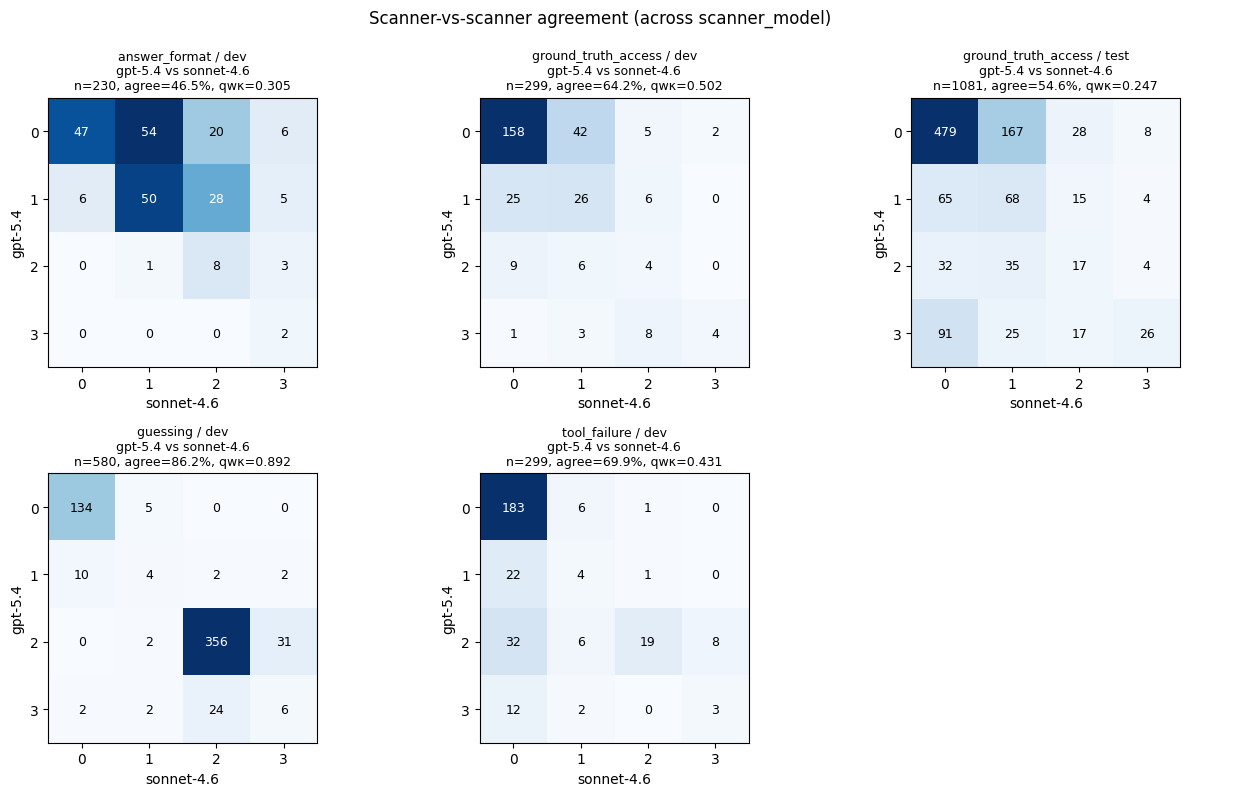

  saved table  → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/scanner_agreement_all_blocks.csv


,target_scanner,split,model_a,model_b,n_paired,agree_rate,mean_abs_diff,quadratic_weighted_kappa
0,answer_format,dev,gpt-5.4,sonnet-4.6,230,46.5%,0.70,0.305
1,ground_truth_access,dev,gpt-5.4,sonnet-4.6,299,64.2%,0.43,0.502
2,ground_truth_access,test,gpt-5.4,sonnet-4.6,1081,54.6%,0.72,0.247
3,guessing,dev,gpt-5.4,sonnet-4.6,580,86.2%,0.15,0.892
4,tool_failure,dev,gpt-5.4,sonnet-4.6,299,69.9%,0.50,0.431


In [8]:
import itertools

# Per-model grade per transcript (avg across multiple scan_ids for the same model).
try:
    per_model
except NameError:
    per_model = (
        combined.dropna(subset=["value_num"])
        .groupby(["target_scanner", "split", "transcript_id", "scanner_model"], dropna=False)["value_num"]
        .mean()
        .reset_index()
    )

block_keys = (
    per_model[["target_scanner", "split"]]
    .drop_duplicates()
    .sort_values(["target_scanner", "split"])
    .to_dict("records")
)

# Build the full list of panels up front so we can size one figure.
panels = []  # each entry: dict with target, split, model_a, model_b, joint
skipped_blocks = []

for block in block_keys:
    target, split = block["target_scanner"], block["split"]
    block_pm = per_model[
        (per_model["target_scanner"] == target) & (per_model["split"] == split)
    ]
    model_order = sorted(block_pm["scanner_model"].dropna().unique().tolist())
    if len(model_order) < 2:
        skipped_blocks.append((target, split, len(model_order)))
        continue
    pivot = block_pm.pivot_table(
        index="transcript_id",
        columns="scanner_model",
        values="value_num",
        aggfunc="first",
    )
    for model_a, model_b in itertools.combinations(model_order, 2):
        if model_a not in pivot.columns or model_b not in pivot.columns:
            continue
        panels.append({
            "target_scanner": target,
            "split": split,
            "model_a": model_a,
            "model_b": model_b,
            "joint": pivot[[model_a, model_b]].dropna(),
        })

for target, split, n_models in skipped_blocks:
    print(f"Only {n_models} scanner_model loaded for {target} / {split} — skipping pairwise agreement.")

all_pair_rows = []

if panels:
    n_panels = len(panels)
    n_cols = min(3, n_panels)
    n_rows = (n_panels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4.4 * n_cols, 4.0 * n_rows),
        squeeze=False,
    )

    for idx, panel in enumerate(panels):
        ax = axes[idx // n_cols][idx % n_cols]
        target = panel["target_scanner"]
        split = panel["split"]
        model_a = panel["model_a"]
        model_b = panel["model_b"]
        joint = panel["joint"]
        block_label = f"{target} / {split}"

        if joint.empty:
            ax.axis("off")
            ax.set_title(f"{block_label}\n{model_a} vs {model_b}\n(no overlap)", fontsize=9)
            continue

        # Floor to int for confusion matrix (per-model values may be non-integer
        # if a model graded the same transcript under multiple scan_ids).
        ga = np.floor(joint[model_a]).astype(int).to_numpy()
        gb = np.floor(joint[model_b]).astype(int).to_numpy()
        cm = confusion_matrix(ga, gb, GRADE_LEVELS)
        kappa = quadratic_weighted_kappa(cm)
        n = int(cm.sum())
        agree = int(np.trace(cm))
        kappa_str = f"{kappa:.3f}" if not np.isnan(kappa) else "—"
        draw_cm(
            ax, cm,
            xlabel=model_b,
            ylabel=model_a,
            title=f"{block_label}\n{model_a} vs {model_b}\nn={n}, agree={agree/n:.1%}, qwκ={kappa_str}",
        )
        all_pair_rows.append({
            "target_scanner": target,
            "split": split,
            "model_a": model_a,
            "model_b": model_b,
            "n_paired": n,
            "agree_rate": agree / n if n else float("nan"),
            "mean_abs_diff": float(np.abs(ga - gb).mean()) if n else float("nan"),
            "quadratic_weighted_kappa": kappa,
        })

    for idx in range(n_panels, n_rows * n_cols):
        axes[idx // n_cols][idx % n_cols].axis("off")

    fig.suptitle("Scanner-vs-scanner agreement (across scanner_model)", y=.99)
    fig.tight_layout()
    save_fig(fig, "scanner_agreement_all_blocks")
    plt.show()

if all_pair_rows:
    pair_df = pd.DataFrame(all_pair_rows).sort_values(
        ["target_scanner", "split", "model_a", "model_b"]
    ).reset_index(drop=True)
    save_table(pair_df, "scanner_agreement_all_blocks")

    display_pair = pair_df.copy()
    display_pair["agree_rate"] = display_pair["agree_rate"].map(
        lambda v: f"{v:.1%}" if pd.notna(v) else "—"
    )
    display_pair["mean_abs_diff"] = display_pair["mean_abs_diff"].map(
        lambda v: f"{v:.2f}" if pd.notna(v) else "—"
    )
    display_pair["quadratic_weighted_kappa"] = display_pair["quadratic_weighted_kappa"].map(
        lambda v: f"{v:.3f}" if pd.notna(v) else "—"
    )
    display(display_pair)


## Performance with Combined Scanner
From the dev set there is some evidence that the cases where scanners agree are more accurate than cases where they disagree. Implementing that here to compare against the post validation grades to see if there is higher accuracy.

## answer_format / dev — Composite scanners (across scanner_model)

Transcripts with grades from ≥2 scanner_models: 230
Contributor-count distribution:
  2 scanner_models → 230 transcripts
  saved figure → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/composite_vs_validation__answer_format__dev.png


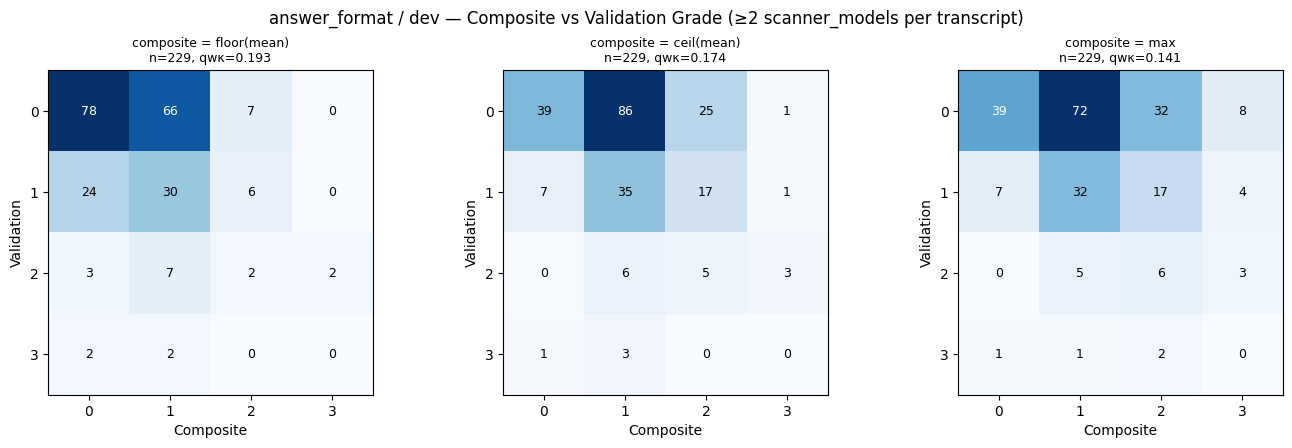

### answer_format / dev — Composite metrics vs validation (threshold = 2)

,composite,n,accuracy,sensitivity,specificity,precision,f1,tp,tn,fp,fn,quadratic_weighted_kappa
0,floor(mean),229,88.2%,22.2%,93.8%,23.5%,0.229,4,198,13,14,0.193
1,ceil(mean),229,76.4%,44.4%,79.1%,15.4%,0.229,8,167,44,10,0.174
2,max,229,70.3%,61.1%,71.1%,15.3%,0.244,11,150,61,7,0.141


  saved table  → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/agreement_partition__answer_format__dev.csv


### answer_format / dev — Performance partitioned by full agreement

,bucket,n_transcripts,n_validated,validation_violation_rate,composite,n,accuracy,sensitivity,specificity,precision,f1,tp,tn,fp,fn
0,all-agree,170,170,6.5%,—,170,90.6%,36.4%,94.3%,30.8%,0.333,4,150,9,7
1,any-disagree,60,59,11.9%,ceil(mean),59,35.6%,57.1%,32.7%,10.3%,0.174,4,17,35,3
2,any-disagree,60,59,11.9%,floor(mean),59,81.4%,0.0%,92.3%,0.0%,0.000,0,48,4,7
3,any-disagree,60,59,11.9%,max,59,11.9%,100.0%,0.0%,11.9%,0.212,7,0,52,0


## answer_format / test — Composite scanners (across scanner_model)

Only 1 scanner_model loaded for answer_format / test — skipping.


## ground_truth_access / dev — Composite scanners (across scanner_model)

Transcripts with grades from ≥2 scanner_models: 299
Contributor-count distribution:
  2 scanner_models → 299 transcripts
  saved figure → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/composite_vs_validation__ground_truth_access__dev.png


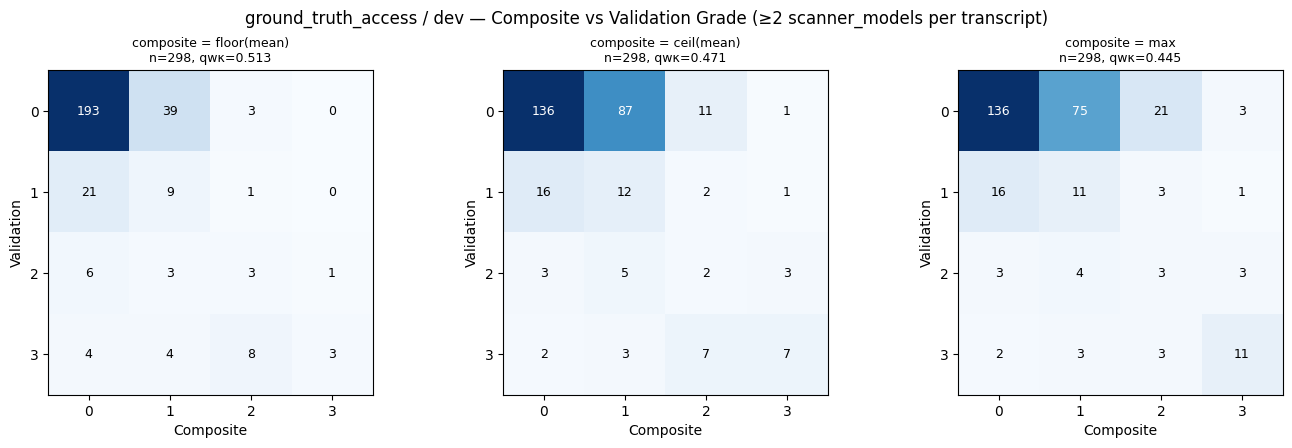

### ground_truth_access / dev — Composite metrics vs validation (threshold = 2)

,composite,n,accuracy,sensitivity,specificity,precision,f1,tp,tn,fp,fn,quadratic_weighted_kappa
0,floor(mean),298,93.0%,46.9%,98.5%,78.9%,0.588,15,262,4,17,0.513
1,ceil(mean),298,90.6%,59.4%,94.4%,55.9%,0.576,19,251,15,13,0.471
2,max,298,86.6%,62.5%,89.5%,41.7%,0.500,20,238,28,12,0.445


  saved table  → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/agreement_partition__ground_truth_access__dev.csv


### ground_truth_access / dev — Performance partitioned by full agreement

,bucket,n_transcripts,n_validated,validation_violation_rate,composite,n,accuracy,sensitivity,specificity,precision,f1,tp,tn,fp,fn
0,all-agree,267,266,9.0%,—,266,94.0%,50.0%,98.3%,75.0%,0.600,12,238,4,12
1,any-disagree,32,32,25.0%,ceil(mean),32,62.5%,87.5%,54.2%,38.9%,0.538,7,13,11,1
2,any-disagree,32,32,25.0%,floor(mean),32,84.4%,37.5%,100.0%,100.0%,0.545,3,24,0,5
3,any-disagree,32,32,25.0%,max,32,25.0%,100.0%,0.0%,25.0%,0.400,8,0,24,0


## ground_truth_access / test — Composite scanners (across scanner_model)

Transcripts with grades from ≥2 scanner_models: 1,081
Contributor-count distribution:
  2 scanner_models → 1081 transcripts
  saved figure → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/composite_vs_validation__ground_truth_access__test.png


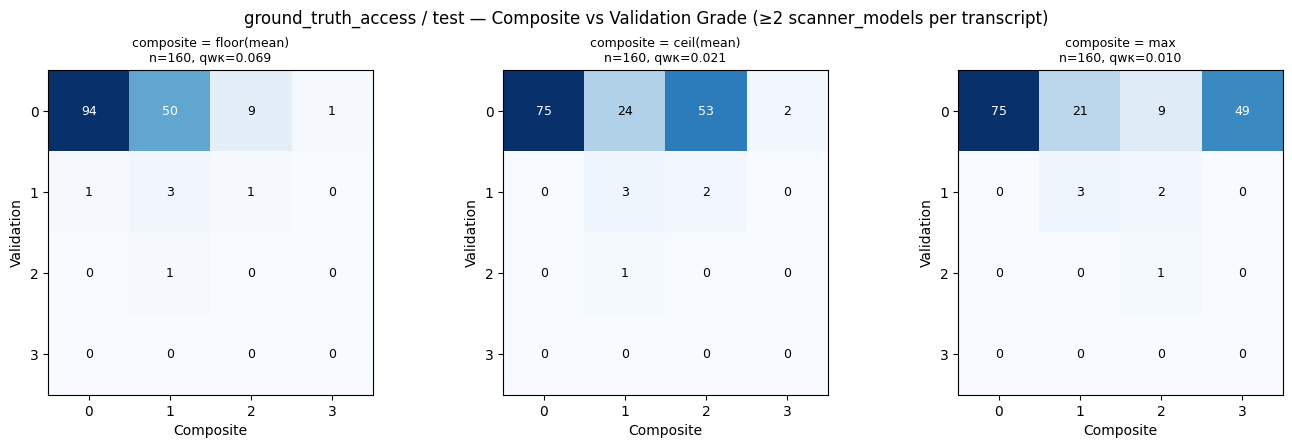

### ground_truth_access / test — Composite metrics vs validation (threshold = 2)

,composite,n,accuracy,sensitivity,specificity,precision,f1,tp,tn,fp,fn,quadratic_weighted_kappa
0,floor(mean),160,92.5%,0.0%,93.1%,0.0%,0.000,0,148,11,1,0.069
1,ceil(mean),160,63.7%,0.0%,64.2%,0.0%,0.000,0,102,57,1,0.021
2,max,160,62.5%,100.0%,62.3%,1.6%,0.032,1,99,60,0,0.010


  saved table  → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/agreement_partition__ground_truth_access__test.csv


### ground_truth_access / test — Performance partitioned by full agreement

,bucket,n_transcripts,n_validated,validation_violation_rate,composite,n,accuracy,sensitivity,specificity,precision,f1,tp,tn,fp,fn
0,all-agree,843,104,0.0%,—,104,95.2%,—,95.2%,0.0%,0.000,0,99,5,0
1,any-disagree,238,56,1.8%,ceil(mean),56,5.4%,0.0%,5.5%,0.0%,0.000,0,3,52,1
2,any-disagree,238,56,1.8%,floor(mean),56,87.5%,0.0%,89.1%,0.0%,0.000,0,49,6,1
3,any-disagree,238,56,1.8%,max,56,1.8%,100.0%,0.0%,1.8%,0.035,1,0,55,0


## guessing / dev — Composite scanners (across scanner_model)

Transcripts with grades from ≥2 scanner_models: 580
Contributor-count distribution:
  2 scanner_models → 580 transcripts
  saved figure → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/composite_vs_validation__guessing__dev.png


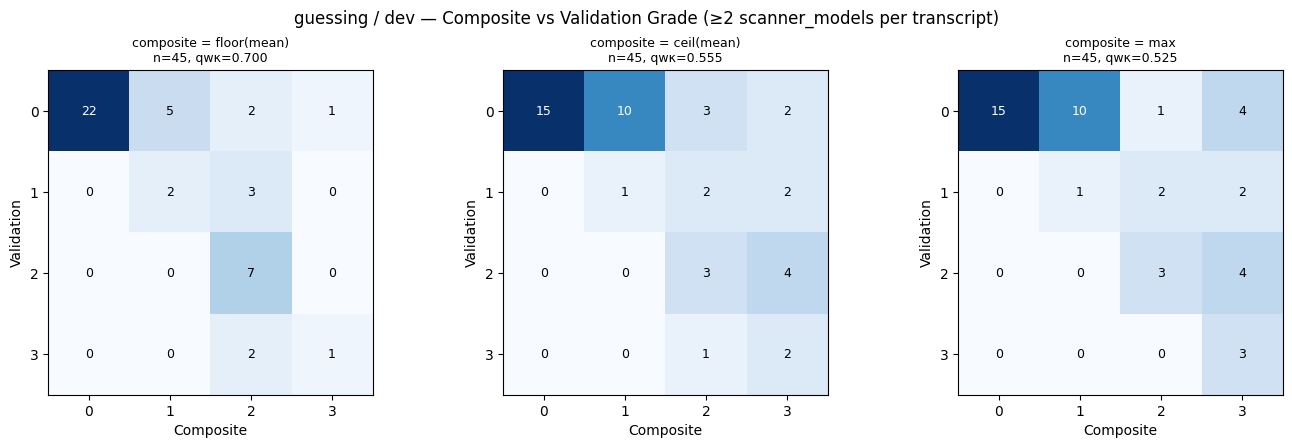

### guessing / dev — Composite metrics vs validation (threshold = 2)

,composite,n,accuracy,sensitivity,specificity,precision,f1,tp,tn,fp,fn,quadratic_weighted_kappa
0,floor(mean),45,86.7%,100.0%,82.9%,62.5%,0.769,10,29,6,0,0.700
1,ceil(mean),45,80.0%,100.0%,74.3%,52.6%,0.690,10,26,9,0,0.555
2,max,45,80.0%,100.0%,74.3%,52.6%,0.690,10,26,9,0,0.525


  saved table  → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/agreement_partition__guessing__dev.csv


### guessing / dev — Performance partitioned by full agreement

,bucket,n_transcripts,n_validated,validation_violation_rate,composite,n,accuracy,sensitivity,specificity,precision,f1,tp,tn,fp,fn
0,all-agree,570,40,22.5%,—,40,87.5%,100.0%,83.9%,64.3%,0.783,9,26,5,0
1,any-disagree,10,5,20.0%,ceil(mean),5,20.0%,100.0%,0.0%,20.0%,0.333,1,0,4,0
2,any-disagree,10,5,20.0%,floor(mean),5,80.0%,100.0%,75.0%,50.0%,0.667,1,3,1,0
3,any-disagree,10,5,20.0%,max,5,20.0%,100.0%,0.0%,20.0%,0.333,1,0,4,0


## guessing / test — Composite scanners (across scanner_model)

Only 1 scanner_model loaded for guessing / test — skipping.


## tool_failure / dev — Composite scanners (across scanner_model)

Transcripts with grades from ≥2 scanner_models: 299
Contributor-count distribution:
  2 scanner_models → 299 transcripts
  saved figure → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/composite_vs_validation__tool_failure__dev.png


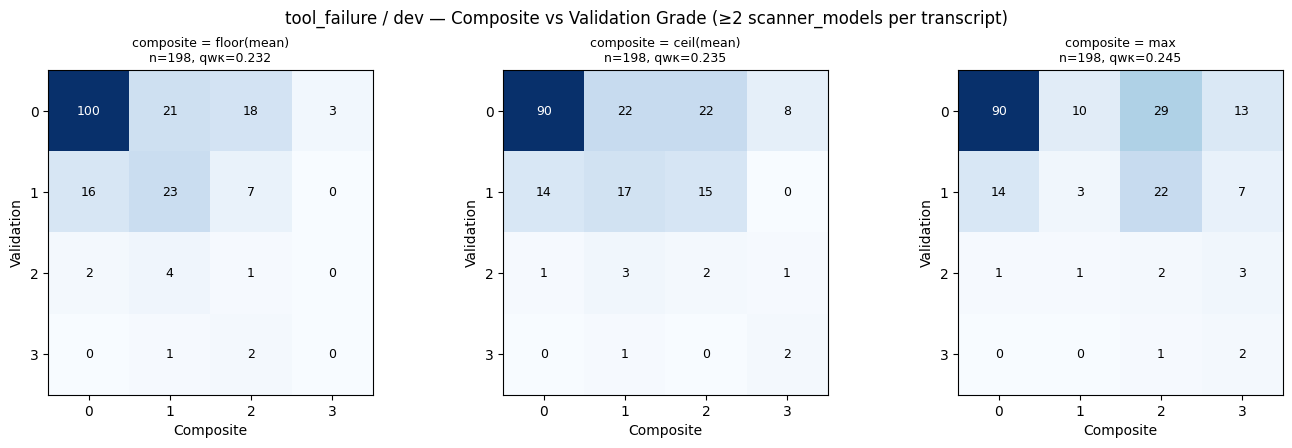

### tool_failure / dev — Composite metrics vs validation (threshold = 2)

,composite,n,accuracy,sensitivity,specificity,precision,f1,tp,tn,fp,fn,quadratic_weighted_kappa
0,floor(mean),198,82.3%,30.0%,85.1%,9.7%,0.146,3,160,28,7,0.232
1,ceil(mean),198,74.7%,50.0%,76.1%,10.0%,0.167,5,143,45,5,0.235
2,max,198,63.1%,80.0%,62.2%,10.1%,0.180,8,117,71,2,0.245


  saved table  → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/agreement_partition__tool_failure__dev.csv


### tool_failure / dev — Performance partitioned by full agreement

,bucket,n_transcripts,n_validated,validation_violation_rate,composite,n,accuracy,sensitivity,specificity,precision,f1,tp,tn,fp,fn
0,all-agree,245,148,3.4%,—,148,81.1%,60.0%,81.8%,10.3%,0.176,3,117,26,2
1,any-disagree,54,50,10.0%,ceil(mean),50,56.0%,40.0%,57.8%,9.5%,0.154,2,26,19,3
2,any-disagree,54,50,10.0%,floor(mean),50,86.0%,0.0%,95.6%,0.0%,0.000,0,43,2,5
3,any-disagree,54,50,10.0%,max,50,10.0%,100.0%,0.0%,10.0%,0.182,5,0,45,0


## tool_failure / test — Composite scanners (across scanner_model)

Only 1 scanner_model loaded for tool_failure / test — skipping.
  saved table  → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/composite_metrics_all_blocks.csv
  saved table  → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/agreement_partition_all_blocks.csv


In [9]:
# Composite scanner analysis — combine across scanner_model within each
# (target_scanner, split) group. Mirrors the per-scan_id composite logic but
# treats each scanner_model as one "voter".

# One per-model grade per transcript: if a model graded a transcript under
# multiple scan_ids, average those grades (then later we floor for integer
# composites — same convention as the per-scan_id version).
per_model = (
    combined.dropna(subset=["value_num"])
    .groupby(["target_scanner", "split", "transcript_id", "scanner_model"], dropna=False)["value_num"]
    .mean()
    .reset_index()
)

# Validation grades are per (target_scanner, split, transcript_id) — already
# merged onto every row in `combined`, so dedupe to one row per transcript.
val_per_block = (
    combined.dropna(subset=["validation_grade"])
    [["target_scanner", "split", "transcript_id", "validation_grade"]]
    .drop_duplicates(["target_scanner", "split", "transcript_id"])
)

block_keys = (
    per_model[["target_scanner", "split"]]
    .drop_duplicates()
    .sort_values(["target_scanner", "split"])
    .to_dict("records")
)

all_metrics_rows = []
all_bucket_rows = []
composite_blocks = []  # collected for the benchmark-level plots in the next cell

for block in block_keys:
    target = block["target_scanner"]
    split = block["split"]
    block_label = f"{target} / {split}"
    display(Markdown(f"## {block_label} — Composite scanners (across scanner_model)"))

    block_pm = per_model[
        (per_model["target_scanner"] == target) & (per_model["split"] == split)
    ]
    model_order = sorted(block_pm["scanner_model"].dropna().unique().tolist())

    if len(model_order) < 2:
        print(f"Only {len(model_order)} scanner_model loaded for {block_label} — skipping.")
        continue

    pivot = block_pm.pivot_table(
        index="transcript_id",
        columns="scanner_model",
        values="value_num",
        aggfunc="first",
    )

    # Require ≥2 scanner_models for a composite to be meaningful.
    grade_count = pivot.notna().sum(axis=1)
    composite = pivot[grade_count >= 2].copy()
    composite["n_scanner_models"] = grade_count[grade_count >= 2]
    composite["composite_floor_mean"] = (
        np.floor(composite[model_order].mean(axis=1, skipna=True)).astype(int)
    )
    composite["composite_ceil_mean"] = (
        np.ceil(composite[model_order].mean(axis=1, skipna=True)).astype(int)
    )
    composite["composite_max"] = composite[model_order].max(axis=1, skipna=True).astype(int)

    composite_blocks.append(
        composite.reset_index()
        .assign(target_scanner=target, split=split)
        [["target_scanner", "split", "transcript_id",
          "composite_floor_mean", "composite_ceil_mean", "composite_max"]]
    )

    print(f"Transcripts with grades from ≥2 scanner_models: {len(composite):,}")
    contributor_counts = composite["n_scanner_models"].value_counts().sort_index()
    print("Contributor-count distribution:")
    for n, count in contributor_counts.items():
        print(f"  {int(n)} scanner_models → {int(count)} transcripts")

    block_val = val_per_block[
        (val_per_block["target_scanner"] == target) & (val_per_block["split"] == split)
    ][["transcript_id", "validation_grade"]]
    has_validation = not block_val.empty

    if not has_validation:
        print("No validation grades for this block — skipping confusion matrices.")
        composite_eval = composite
    else:
        composite_eval = composite.merge(
            block_val.set_index("transcript_id"),
            left_index=True, right_index=True, how="left",
        )

    composites = [
        ("floor(mean)", "composite_floor_mean"),
        ("ceil(mean)", "composite_ceil_mean"),
        ("max", "composite_max"),
    ]

    if has_validation:
        scored = composite_eval.dropna(subset=["validation_grade"]).copy()
        scored["validation_int"] = scored["validation_grade"].astype(int)
        if scored.empty:
            print("No transcripts with both ≥2 scanner_model grades and a validation grade.")
        else:
            fig, axes = plt.subplots(
                1, len(composites),
                figsize=(4.6 * len(composites), 4.4),
                squeeze=False,
            )
            metrics_rows = []
            for ax, (name, col) in zip(axes[0], composites):
                tgt = scored["validation_int"].to_numpy()
                pred = scored[col].astype(int).to_numpy()
                cm = confusion_matrix(tgt, pred, GRADE_LEVELS)
                kappa = quadratic_weighted_kappa(cm)
                metrics = threshold_metrics(tgt, pred, threshold=VIOLATION_THRESHOLD)
                kappa_str = f"{kappa:.3f}" if not np.isnan(kappa) else "—"
                draw_cm(
                    ax, cm,
                    xlabel="Composite",
                    ylabel="Validation",
                    title=f"composite = {name}\nn={metrics['n']}, qwκ={kappa_str}",
                )
                metrics_rows.append({
                    "target_scanner": target, "split": split,
                    "composite": name, **metrics,
                    "quadratic_weighted_kappa": kappa,
                })
            fig.suptitle(
                f"{block_label} — Composite vs Validation Grade "
                f"(≥2 scanner_models per transcript)", y=.98,
            )
            fig.tight_layout()
            save_fig(fig, f"composite_vs_validation__{target}__{split}")
            plt.show()

            metrics_df = pd.DataFrame(metrics_rows)
            all_metrics_rows.extend(metrics_rows)
            display_metrics = metrics_df.drop(columns=["target_scanner", "split"]).copy()
            for col in ["accuracy", "sensitivity", "specificity", "precision"]:
                display_metrics[col] = display_metrics[col].map(
                    lambda v: f"{v:.1%}" if pd.notna(v) else "—"
                )
            display_metrics["f1"] = display_metrics["f1"].map(
                lambda v: f"{v:.3f}" if pd.notna(v) else "—"
            )
            display_metrics["quadratic_weighted_kappa"] = display_metrics["quadratic_weighted_kappa"].map(
                lambda v: f"{v:.3f}" if pd.notna(v) else "—"
            )
            display(Markdown(
                f"### {block_label} — Composite metrics vs validation "
                f"(threshold = {VIOLATION_THRESHOLD})"
            ))
            display(display_metrics)

    # Agreement partition: per transcript, look only at the scanner_models
    # that actually graded it (NaN columns are ignored).
    grade_only = composite[model_order]
    flags = grade_only >= VIOLATION_THRESHOLD          # NaN → False
    flags_neg = grade_only < VIOLATION_THRESHOLD       # NaN → False
    n_pos = flags.sum(axis=1)
    n_neg = flags_neg.sum(axis=1)
    n_total = composite["n_scanner_models"]

    bucket = pd.Series("any-disagree", index=composite.index)
    bucket[(n_pos == n_total) | (n_neg == n_total)] = "all-agree"
    composite["agreement_bucket"] = bucket

    summary_rows = []
    for b, group in composite.groupby("agreement_bucket"):
        base = {
            "target_scanner": target, "split": split,
            "bucket": b, "n_transcripts": int(len(group)),
        }

        if not has_validation:
            summary_rows.append({**base, "composite": "—"})
            continue

        with_val = group.merge(
            block_val.set_index("transcript_id"),
            left_index=True, right_index=True, how="left",
        ).dropna(subset=["validation_grade"])

        if with_val.empty:
            summary_rows.append({
                **base,
                "composite": "—",
                "n_validated": 0,
                "validation_violation_rate": float("nan"),
            })
            continue

        v_int = with_val["validation_grade"].astype(int).to_numpy()
        common = {
            **base,
            "n_validated": int(len(with_val)),
            "validation_violation_rate": float((v_int >= VIOLATION_THRESHOLD).mean()),
        }

        # In the all-agree bucket, every scanner_model is on the same side of
        # the threshold, so floor(mean), ceil(mean), and max produce identical
        # thresholded predictions — emit one row.
        if b == "all-agree":
            pred_int = with_val[composites[0][1]].astype(int).to_numpy()
            metrics = threshold_metrics(v_int, pred_int, threshold=VIOLATION_THRESHOLD)
            summary_rows.append({**common, "composite": "—", **metrics})
        else:
            for name, col in composites:
                pred_int = with_val[col].astype(int).to_numpy()
                metrics = threshold_metrics(v_int, pred_int, threshold=VIOLATION_THRESHOLD)
                summary_rows.append({**common, "composite": name, **metrics})

    if not summary_rows:
        print(f"{block_label}: composite frame is empty — no agreement partition to report.")
        continue

    bucket_df = (
        pd.DataFrame(summary_rows)
        .sort_values(["bucket", "composite"])
        .reset_index(drop=True)
    )
    all_bucket_rows.extend(summary_rows)
    save_table(bucket_df, f"agreement_partition__{target}__{split}")

    display_bucket = bucket_df.drop(columns=["target_scanner", "split"]).copy()
    if "validation_violation_rate" in display_bucket.columns:
        display_bucket["validation_violation_rate"] = display_bucket["validation_violation_rate"].map(
            lambda v: f"{v:.1%}" if pd.notna(v) else "—"
        )
    for col in ["accuracy", "sensitivity", "specificity", "precision"]:
        if col in display_bucket.columns:
            display_bucket[col] = display_bucket[col].map(
                lambda v: f"{v:.1%}" if pd.notna(v) else "—"
            )
    if "f1" in display_bucket.columns:
        display_bucket["f1"] = display_bucket["f1"].map(
            lambda v: f"{v:.3f}" if pd.notna(v) else "—"
        )
    display(Markdown(f"### {block_label} — Performance partitioned by full agreement"))
    display(display_bucket)

# Combined cross-block tables (saved once, for cross-block comparison).
if all_metrics_rows:
    save_table(pd.DataFrame(all_metrics_rows), "composite_metrics_all_blocks")
if all_bucket_rows:
    save_table(pd.DataFrame(all_bucket_rows), "agreement_partition_all_blocks")

# Stash the long-form composite grades for the benchmark-level plot cell below.
composite_long = (
    pd.concat(composite_blocks, ignore_index=True)
    if composite_blocks else pd.DataFrame(
        columns=["target_scanner", "split", "transcript_id",
                 "composite_floor_mean", "composite_ceil_mean", "composite_max"],
    )
)


## Composite grade distributions per benchmark

Same layout as the per-`scanner_model` `Grade distributions per target scanner`
plot earlier in the notebook, but each bar is the distribution of a *composite*
grade (one per `(target_scanner, split, transcript_id)`). One figure per
composite approach (`floor(mean)`, `ceil(mean)`, `max`); one panel per
`target_scanner`; bars over `(split, benchmark)`. Grade 0 is omitted, as in the
earlier stacked plot.

  saved figure → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/composite_grade_distribution__composite_floor_mean.png


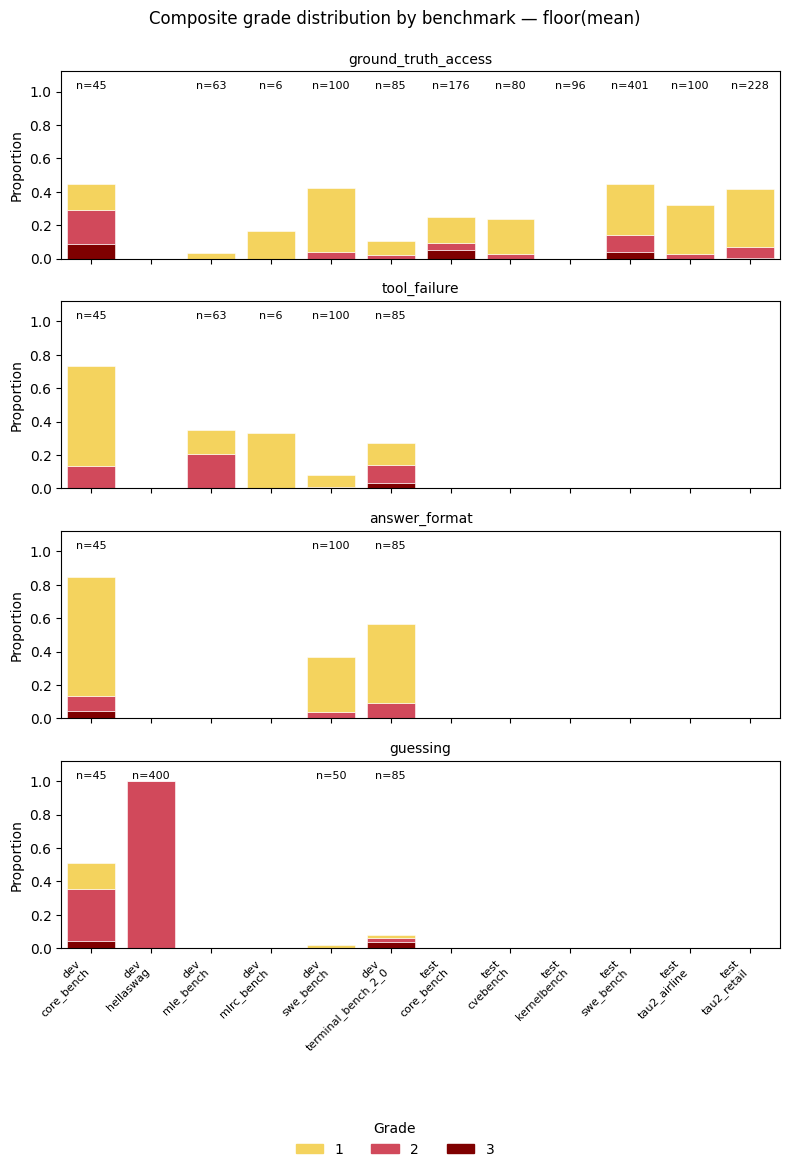

  saved figure → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/composite_grade_distribution__composite_ceil_mean.png


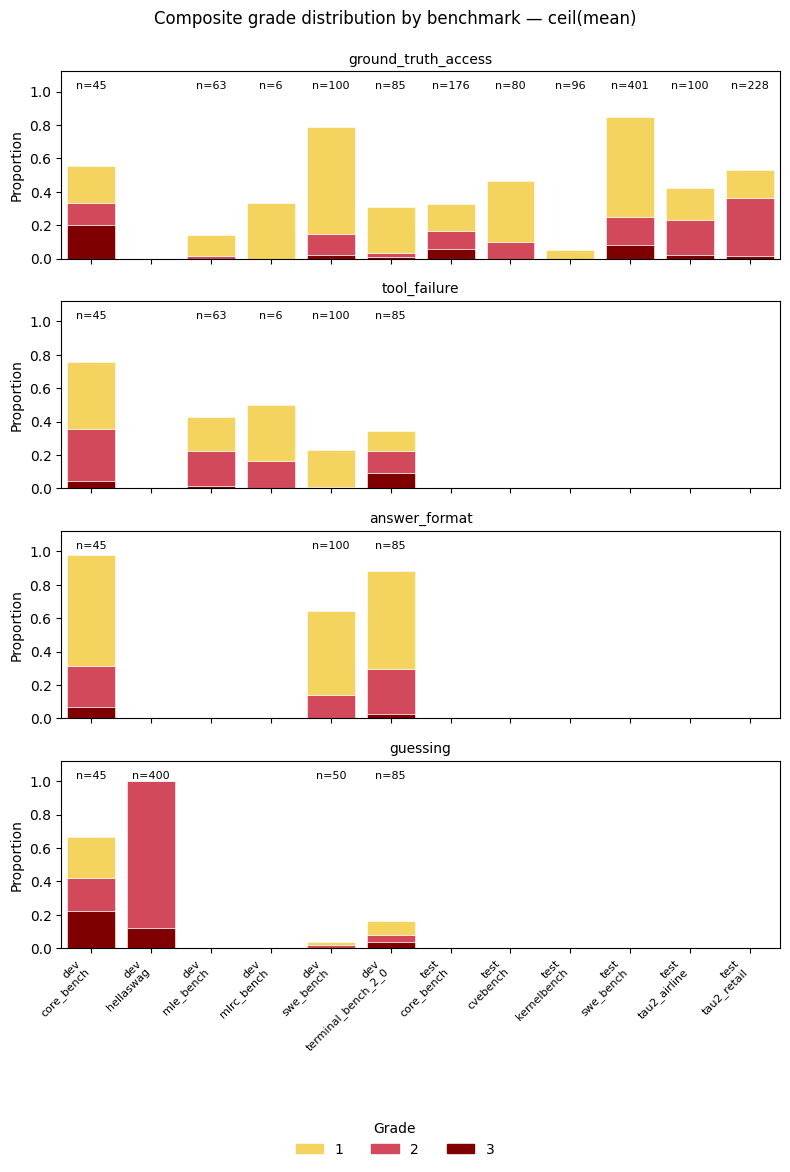

  saved figure → /home/jeffm/projects/scanner_evaluation/analysis/results/combined/combined_dev_test/composite_grade_distribution__composite_max.png


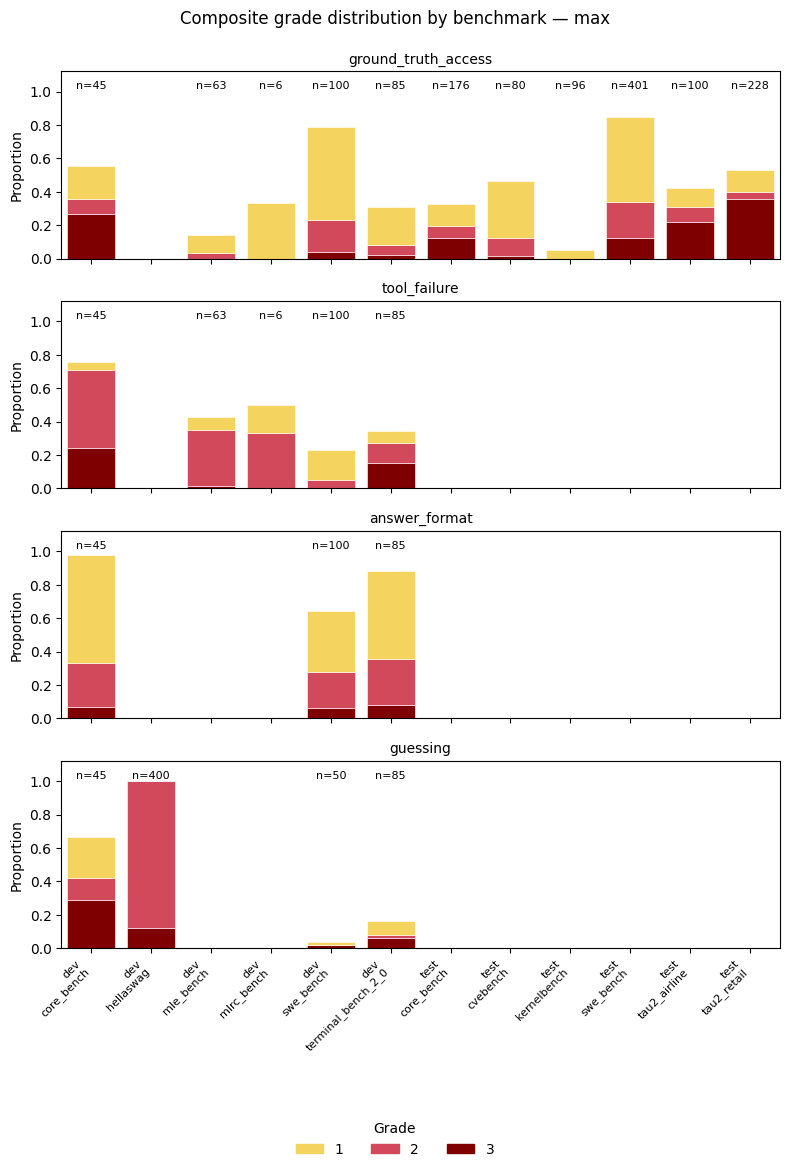

In [10]:
if composite_long.empty:
    print("No composite grades available — nothing to plot.")
else:
    # Attach benchmark via combined (transcript_id is unique within a block).
    transcript_meta = (
        combined.dropna(subset=["benchmark"])
        [["target_scanner", "split", "transcript_id", "benchmark"]]
        .drop_duplicates(["target_scanner", "split", "transcript_id"])
    )
    plot_df = composite_long.merge(
        transcript_meta, on=["target_scanner", "split", "transcript_id"], how="left",
    )

    composites = [
        ("floor(mean)", "composite_floor_mean"),
        ("ceil(mean)", "composite_ceil_mean"),
        ("max", "composite_max"),
    ]

    preferred_scanner_order = ["ground_truth_access", "tool_failure", "answer_format"]
    target_scanners = sorted(
        plot_df["target_scanner"].dropna().unique().tolist(),
        key=lambda s: (
            preferred_scanner_order.index(s) if s in preferred_scanner_order
            else len(preferred_scanner_order)
        ),
    )

    split_order = ["dev", "test"]
    available_splits = [s for s in split_order if s in plot_df["split"].unique()]
    available_splits += [
        s for s in plot_df["split"].dropna().unique() if s not in split_order
    ]
    ordered_keys = []
    for split_val in available_splits:
        bench = (
            plot_df[plot_df["split"] == split_val]
            .dropna(subset=["benchmark"])["benchmark"]
            .drop_duplicates()
            .sort_values()
            .tolist()
        )
        ordered_keys.extend((split_val, b) for b in bench)

    # Drop grade 0 to match the earlier stacked plot.
    grades_present = sorted(
        pd.concat([plot_df[c] for _, c in composites]).dropna().astype(int).unique()
    )
    plot_grades = [g for g in grades_present if g >= 1]

    for name, col in composites:
        n_panels = len(target_scanners)
        fig, axes = plt.subplots(
            n_panels, 1,
            figsize=(max(4.0, 0.5 * len(ordered_keys) + 2), 2.8 * n_panels),
            sharey=True, sharex=True, squeeze=False,
        )
        n_keys = len(ordered_keys)
        x = np.arange(n_keys)
        xtick_labels = [f"{s}\n{b}" for s, b in ordered_keys]

        for idx, target in enumerate(target_scanners):
            ax = axes[idx][0]
            panel_df = plot_df[plot_df["target_scanner"] == target]

            props_by_grade = {g: [] for g in plot_grades}
            group_n = []
            for split_val, bench in ordered_keys:
                cell = panel_df[
                    (panel_df["split"] == split_val) & (panel_df["benchmark"] == bench)
                ][col].dropna().astype(int)
                total = len(cell)
                group_n.append(total)
                for g in plot_grades:
                    props_by_grade[g].append((cell == g).sum() / total if total else 0)

            bottom = np.zeros(n_keys)
            for grade in reversed(plot_grades):
                heights = np.array(props_by_grade[grade])
                ax.bar(x, heights, 0.8, bottom=bottom,
                       color=SCORE_COLORS.get(grade, "#999999"),
                       edgecolor="white", linewidth=0.4)
                bottom += heights

            for xi, n in zip(x, group_n):
                if n > 0:
                    ax.text(xi, 1.005, f"n={n}", ha="center", va="bottom", fontsize=8)

            ax.set_xticks(x)
            ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=8)
            ax.set_xlim(-0.5, n_keys - 0.5)
            ax.set_ylim(0, 1.12)
            ax.set_ylabel("Proportion")
            ax.set_title(target, fontsize=10)

        grade_handles = [
            plt.Rectangle((0, 0), 1, 1, color=SCORE_COLORS.get(g, "#999999"))
            for g in plot_grades
        ]
        fig.legend(
            grade_handles, [str(g) for g in plot_grades], title="Grade",
            loc="lower center", bbox_to_anchor=(0.5, -0.04),
            ncol=len(plot_grades), frameon=False,
        )
        fig.suptitle(f"Composite grade distribution by benchmark — {name}", y=0.995)
        fig.tight_layout(rect=[0, 0.05, 1, 1])
        save_fig(fig, f"composite_grade_distribution__{col}")
        plt.show()
